In [68]:
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
import matplotlib
from PIL import Image

import matplotlib.animation as animation
from IPython.display import HTML

In [ ]:
def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())
    
class Ellipsoid:
    def __init__(self, a=1.0, b=1.0, c=1.0):
        """
        Initialize an ellipsoid with semi-axes a, b, c.
        """
        self.a = a
        self.b = b
        self.c = c

    def r(self, theta, phi):
        """
        Convert (theta, phi) to 3D Cartesian coordinates on the ellipsoid surface.

        Parameters:
        - theta: azimuthal angle [0, 2π]
        - phi: polar angle [0, π]

        Returns:
        - np.array([x, y, z])
        """
        x = self.a * np.sin(phi) * np.cos(theta)
        y = self.b * np.sin(phi) * np.sin(theta)
        z = self.c * np.cos(phi)
        return np.array([x, y, z])

    def theta_phi(self, r_vec):
        """
        Convert a 3D point to spherical angles (theta, phi).

        Parameters:
        - r_vec: np.array([x, y, z])

        Returns:
        - theta: azimuthal angle [0, 2π]
        - phi: polar angle [0, π]
        """
        x, y, z = r_vec
        r = np.linalg.norm(r_vec)
        theta = np.arctan2(y, x)
        phi = np.arccos(z / r)
        return theta, phi

    def surface_normal(self, theta, phi):
        """
        Compute the unit surface normal at (theta, phi) on the ellipsoid.

        Parameters:
        - theta: azimuthal angle
        - phi: polar angle

        Returns:
        - np.array([nx, ny, nz])
        """
        p = self.r(theta, phi)
        x, y, z = p

        nx = x / (self.a ** 2)
        ny = y / (self.b ** 2)
        nz = z / (self.c ** 2)

        n = np.array([nx, ny, nz])
        return n / np.linalg.norm(n)

    def generate_mesh(self, resolution=50):
        theta = np.linspace(0, 2 * np.pi, resolution)
        phi = np.linspace(0, np.pi, resolution)
        theta_grid, phi_grid = np.meshgrid(theta, phi)

        x = self.a * np.sin(phi_grid) * np.cos(theta_grid)
        y = self.b * np.sin(phi_grid) * np.sin(theta_grid)
        z = self.c * np.cos(phi_grid)

        return x, y, z
    
    def sample_surface_points(self, n_points=2, seed=None):
        """
        Randomly sample points on the surface of the ellipsoid.

        Parameters:
        - n_points: number of points to sample (default=2)
        - seed: optional random seed for reproducibility

        Returns:
        - points: list of np.array([x, y, z]) on the ellipsoid surface
        """
        if seed is not None:
            np.random.seed(seed)

        # Uniform sampling on the sphere using spherical coordinates
        u = np.random.uniform(0, 1, n_points)
        v = np.random.uniform(0, 1, n_points)
        theta = 2 * np.pi * u            # azimuthal angle [0, 2π]
        phi = np.arccos(2 * v - 1)       # polar angle [0, π], uniformly on sphere

        points = [self.r(t, p) for t, p in zip(theta, phi)]
        return points
    
    def project_to_surface(self, point):
        """
        Project a 3D point onto the ellipsoid surface.

        Parameters:
        - point: np.array([x, y, z])

        Returns:
        - np.array([x_proj, y_proj, z_proj]) on the ellipsoid surface
        """
        x, y, z = point
        denom = ((x / self.a) ** 2 +
                 (y / self.b) ** 2 +
                 (z / self.c) ** 2)

        if denom == 0:
            raise ValueError("Cannot project the origin onto the ellipsoid.")

        scale = 1 / np.sqrt(denom)
        return scale * np.array([x, y, z])
    
    def sample_close_surface_points(self, epsilon=0.01, seed=None):
        """
        Sample two nearby points on the ellipsoid surface.

        Parameters:
        - epsilon: small angular perturbation (~0.01 rad = ~0.5 deg)
        - seed: random seed for reproducibility

        Returns:
        - point1, point2: two np.array([x, y, z]) points close to each other on the surface
        """
        if seed is not None:
            np.random.seed(seed)

        # Step 1: sample random base angles
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.random.uniform(0, np.pi)

        # Step 2: apply small perturbation
        dtheta = np.random.uniform(-epsilon, epsilon)
        dphi = np.random.uniform(-epsilon, epsilon)

        theta2 = np.clip(theta + dtheta, 0, 2 * np.pi)
        phi2 = np.clip(phi + dphi, 0, np.pi)

        # Step 3: compute 3D points
        p1 = self.r(theta, phi)
        p2 = self.r(theta2, phi2)

        return [p1, p2]

def set_axes_equal(ax):
    """
    Set equal aspect ratio in 3D plot — so that x, y, z units are the same.
    """
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    centers = np.mean(limits, axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

In [70]:
# Ellipsoid parameters
a = 3
b= 1
c = 1

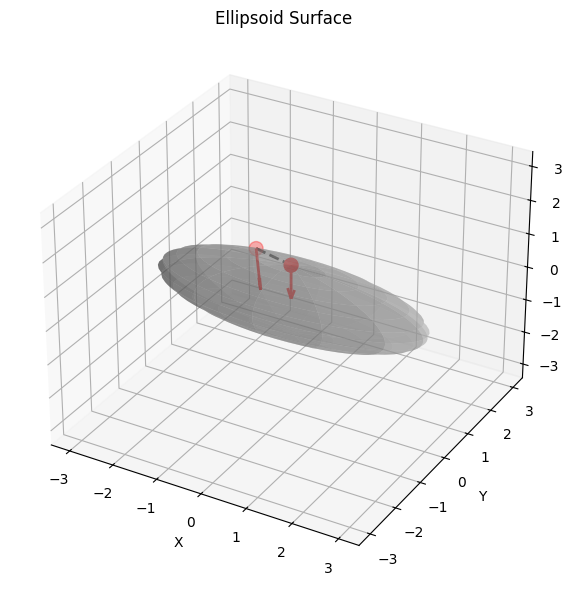

In [74]:
# Create ellipsoid and generate mesh
ellipsoid = Ellipsoid(a=a, b=b, c=c)
x, y, z = ellipsoid.generate_mesh(resolution=50)

# Plot with matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

points = ellipsoid.sample_close_surface_points(epsilon=5, seed=None)
ax.scatter3D(*zip(*points), color='red', s=100)
ax.plot3D(*zip(*points), color='k', linewidth=2, linestyle='--')
normal_1 = -ellipsoid.surface_normal(*ellipsoid.theta_phi(points[0]))
normal_2 = -ellipsoid.surface_normal(*ellipsoid.theta_phi(points[1]))
ax.quiver(*points[0], *normal_1, color='red', length=1, linewidth=2)
ax.quiver(*points[1], *normal_2, color='red', length=1, linewidth=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ellipsoid Surface')
set_axes_equal(ax)

plt.tight_layout()
plt.show()

In [79]:
x1_init = points[0]
x2_init = points[1]
n1_init = -ellipsoid.surface_normal(*ellipsoid.theta_phi(x1_init))
n2_init = -ellipsoid.surface_normal(*ellipsoid.theta_phi(x2_init))
theta1_init = np.arccos((x2_init - x1_init).dot(n2_init) / np.linalg.norm(x2_init - x1_init))
theta2_init = np.arccos((x1_init - x2_init).dot(n1_init) / np.linalg.norm(x1_init - x2_init))

eta = 0.001

list_x1 = [x1_init.reshape(1, -1)]
list_x2 = [x2_init.reshape(1, -1)]
list_n1 = [n1_init.reshape(1, -1)]
list_n2 = [n2_init.reshape(1, -1)]
list_theta1 = [theta1_init]
list_theta2 = [theta2_init]

x1 = x1_init
x2 = x2_init
for iter_ in range(10000):
    n1 = -ellipsoid.surface_normal(*ellipsoid.theta_phi(x1))
    n2 = -ellipsoid.surface_normal(*ellipsoid.theta_phi(x2))   
    diff_vec = x2 - x1
    e = diff_vec / np.linalg.norm(diff_vec)
    theta1 = np.arccos((-e*n2).sum())
    theta2 = np.arccos((e*n1).sum())

    t1 = n2 - (n2*e).sum()*e
    t2 = n1 - (n1*e).sum()*e

    t1 = t1 - (t1*n1).sum()*n1
    t2 = t2 - (t2*n2).sum()*n2

    x1 = x1 + eta*t1
    x2 = x2 + eta*t2

    x1 = ellipsoid.project_to_surface(x1)
    x2 = ellipsoid.project_to_surface(x2)

    list_x1.append(x1.reshape(1, -1))
    list_x2.append(x2.reshape(1, -1))
    list_n1.append(n1.reshape(1, -1))
    list_n2.append(n2.reshape(1, -1))
    list_theta1.append(theta1)
    list_theta2.append(theta2)

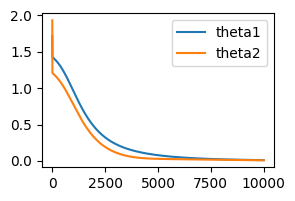

In [80]:
# plot theta as a function for iterations
plt.figure(figsize=(3, 2))
plt.plot(list_theta1, label='theta1')
plt.plot(list_theta2, label='theta2')
plt.legend()
plt.show()

In [ ]:
X1_original = np.concatenate(list_x1, axis=0)
X2_original = np.concatenate(list_x2, axis=0)
N1_original = np.concatenate(list_n1, axis=0)
N2_original = np.concatenate(list_n2, axis=0)
THETA1_original = np.array(list_theta1)
THETA2_original = np.array(list_theta2)

In [ ]:
video = []
skip_frame = 100
for k, (x1, x2, n1, n2, theta1, theta2) in enumerate(zip(
    X1_original[::skip_frame], 
    X2_original[::skip_frame], 
    N1_original[::skip_frame], 
    N2_original[::skip_frame], 
    THETA1_original[::skip_frame], 
    THETA2_original[::skip_frame]
)):
    ellipsoid = Ellipsoid(a=a, b=b, c=c)
    x, y, z = ellipsoid.generate_mesh(resolution=50)

    # Plot with matplotlib
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

    if (theta1 < 5*np.pi/180) and (theta2 < 5*np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.scatter3D(*zip(x1, x2), color=color, s=100)
    if color == 'green':
        ax.plot3D(*zip(x1, x2), color=color, linewidth=2, linestyle='--')
    else:
        ax.plot3D(*zip(x1, x2), color='k', linewidth=2, linestyle='--')
    ax.quiver(*x1, *n1, color=color, length=1, linewidth=2)
    ax.quiver(*x2, *n2, color=color, length=1, linewidth=2)
    set_axes_equal(ax)
    
    # add title with theta 1 and theta 2
    ax.set_title(f'Theta1: {theta1*180/np.pi:.2f} deg, Theta2: {theta2*180/np.pi:.2f} deg')

    buf = BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)  
    plt.close()
    video.append(np.array(Image.open(buf)))

In [83]:
display_video(video, framerate=30)

## Drawing a figure

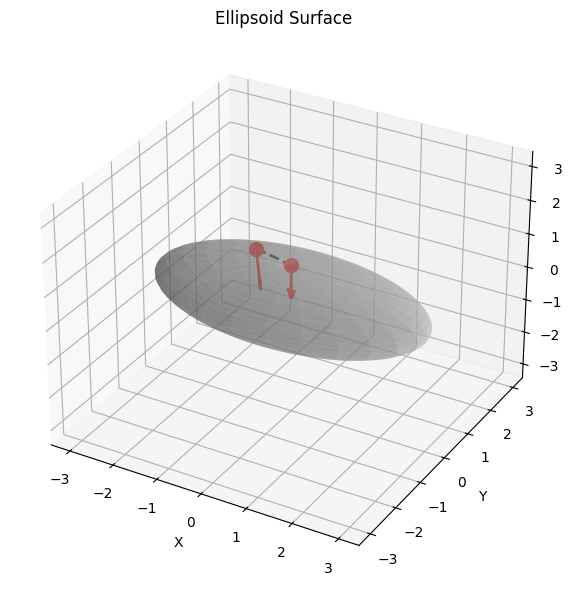

In [86]:
# slicing
X1 = X1_original[::1000]
X2 = X2_original[::1000]
N1 = N1_original[::1000]
N2 = N2_original[::1000]
THETA1 = THETA1_original[::1000]
THETA2 = THETA2_original[::1000]

# Create ellipsoid and generate mesh
ellipsoid = Ellipsoid(a=3.0, b=1.5, c=1.0)
x, y, z = ellipsoid.generate_mesh(resolution=100)

# Plot with matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

# plot line conntecting X1 and X2
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'k'
    ax.plot3D([X1[i, 0], X2[i, 0]], [X1[i, 1], X2[i, 1]], [X1[i, 2], X2[i, 2]], color=color, linewidth=2, linestyle='--')
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.quiver(X1[i, 0], X1[i, 1], X1[i, 2], N1[i, 0], N1[i, 1], N1[i, 2], color=color, length=1, linewidth=2)
    ax.quiver(X2[i, 0], X2[i, 1], X2[i, 2], N2[i, 0], N2[i, 1], N2[i, 2], color=color, length=1, linewidth=2)

# scatter with different color
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.scatter3D(X1[i, 0], X1[i, 1], X1[i, 2], color=color, s=100)
    ax.scatter3D(X2[i, 0], X2[i, 1], X2[i, 2], color=color, s=100)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ellipsoid Surface')
set_axes_equal(ax)

plt.tight_layout()
plt.show()